In [1]:
import sys
print(sys.executable)
print(sys.version)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller # For stationarity test
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # For autocorrelation analysis
from statsmodels.tsa.arima.model import ARIMA # For ARIMA modeling

print("Packages loaded successfully.")

/opt/anaconda3/envs/dissertation/bin/python
3.11.15 (main, Mar 11 2026, 17:14:47) [Clang 20.1.8 ]
Packages loaded successfully.


In [2]:
ticker = "AAPL"

data = yf.download(
    ticker,
    start="2010-01-01",
    end="2024-12-31",
    auto_adjust=False,
    progress=False
)

data.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2010-01-04,6.406481,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.417556,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.315477,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.303801,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.345710,7.570714,7.571429,7.466429,7.510714,447610800


In [3]:
data["log_return"] = np.log(data["Adj Close"] / data["Adj Close"].shift(1))
data = data.dropna()

returns = data["log_return"]

returns.head()

Date
2010-01-05    0.001727
2010-01-06   -0.016034
2010-01-07   -0.001850
2010-01-08    0.006626
2010-01-11   -0.008861
Name: log_return, dtype: float64

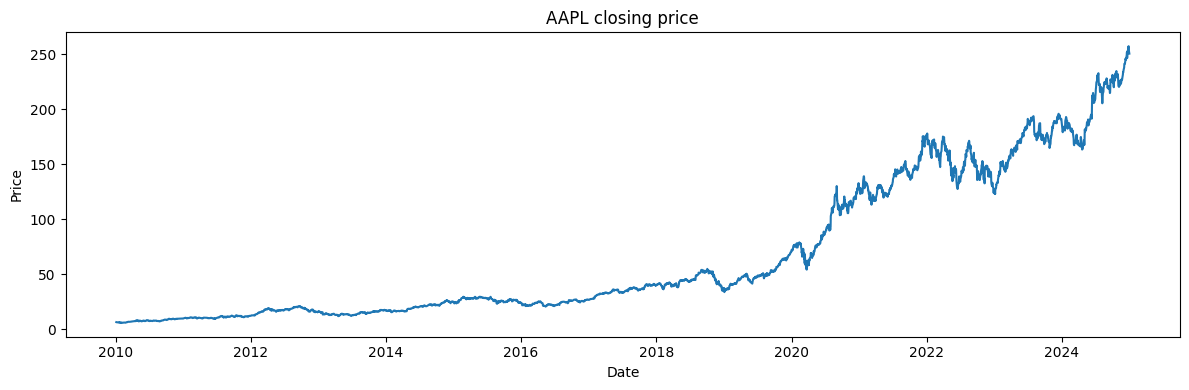

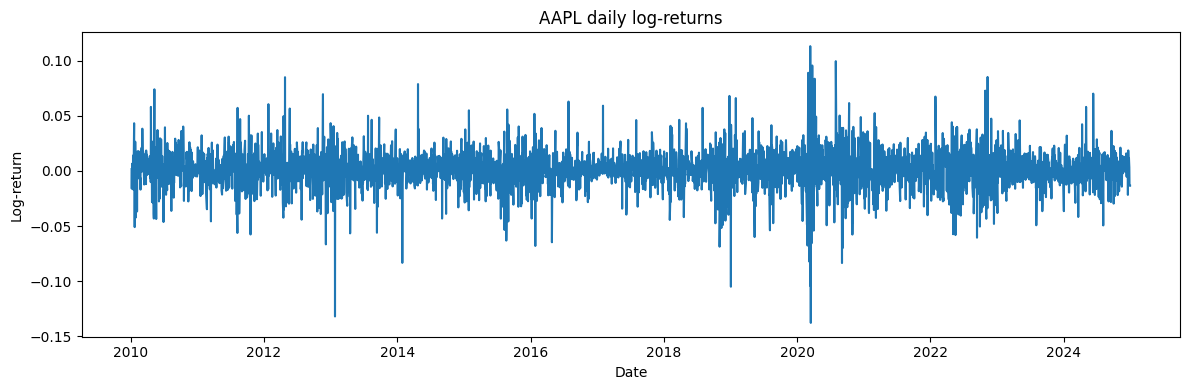

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(data.index, data["Adj Close"])
plt.title("AAPL closing price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(returns.index, returns)
plt.title("AAPL daily log-returns")
plt.xlabel("Date")
plt.ylabel("Log-return")
plt.tight_layout()
plt.show()

In [5]:
adf_result = adfuller(returns)

print("ADF statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of lags used:", adf_result[2])
print("Number of observations:", adf_result[3])

ADF statistic: -20.324546881263412
p-value: 0.0
Number of lags used: 8
Number of observations: 3763


In [6]:
price_series = data["Close"]

adf_price = adfuller(price_series)

print("ADF statistic:", adf_price[0])
print("p-value:", adf_price[1])

ADF statistic: 1.6434834591947818
p-value: 0.997982340222644


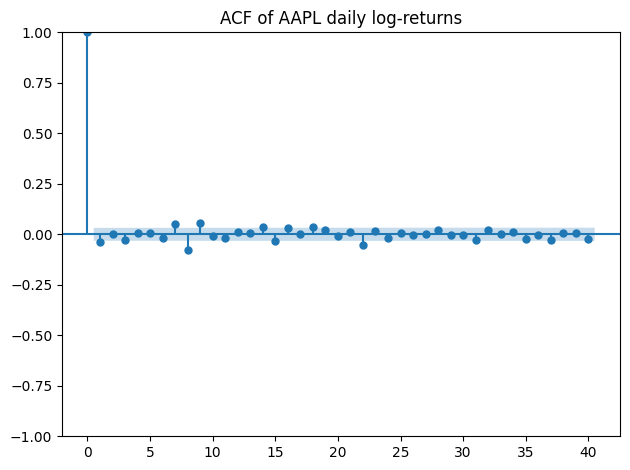

In [7]:
plot_acf(returns, lags=40)
plt.title("ACF of AAPL daily log-returns")
plt.tight_layout()
plt.show()

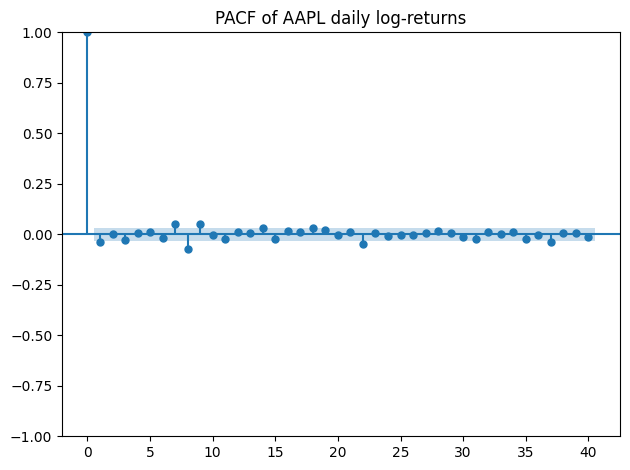

In [8]:
plot_pacf(returns, lags=40, method="ywm")
plt.title("PACF of AAPL daily log-returns")
plt.tight_layout()
plt.show()

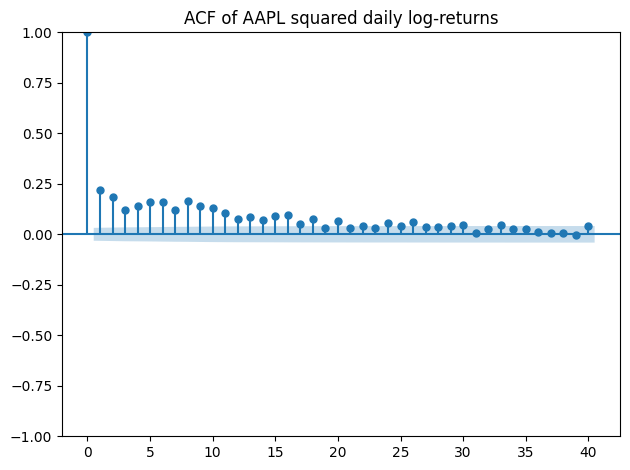

In [9]:
squared_returns = returns ** 2

plot_acf(squared_returns, lags=40)
plt.title("ACF of AAPL squared daily log-returns")
plt.tight_layout()
plt.show()

In [10]:
train = returns.loc["2010-01-01":"2019-12-31"]
test = returns.loc["2020-01-01":"2024-12-31"]

print("Train observations:", len(train))
print("Test observations:", len(test))

Train observations: 2515
Test observations: 1257


In [11]:
arma_model = ARIMA(train, order=(1, 0, 1))
arma_result = arma_model.fit()

print(arma_result.summary())

                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 2515
Model:                 ARIMA(1, 0, 1)   Log Likelihood                6794.028
Date:                Thu, 25 Jun 2026   AIC                         -13580.056
Time:                        18:45:38   BIC                         -13556.736
Sample:                             0   HQIC                        -13571.593
                               - 2515                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.000      2.675      0.007       0.000       0.002
ar.L1          0.4957      0.746      0.664      0.507      -0.967       1.958
ma.L1         -0.4792      0.753     -0.636      0.5

/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [12]:
# Generate ARMA forecasts for the entire test period
arma_forecast = arma_result.forecast(steps=len(test))

# Statsmodels creates an integer index.
# Replace it with the actual test dates.
arma_forecast.index = test.index

arma_forecast.head()

/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Date
2020-01-02    0.001131
2020-01-03    0.001041
2020-01-06    0.000996
2020-01-07    0.000974
2020-01-08    0.000963
Name: predicted_mean, dtype: float64

In [13]:
# Create a table containing actual returns and ARMA forecasts
comparison = pd.DataFrame({
    "actual": test,
    "arma_forecast": arma_forecast
})

# Mean-return baseline:
# predict the historical training-period average every day
mean_forecast_value = float(train.mean())
comparison["mean_forecast"] = mean_forecast_value

print("Comparison columns:", comparison.columns.tolist())

comparison.head()

Comparison columns: ['actual', 'arma_forecast', 'mean_forecast']


,actual,arma_forecast,mean_forecast
Date,,,
2020-01-02,0.022560,0.001131,0.000955
2020-01-03,-0.009770,0.001041,0.000955
2020-01-06,0.007937,0.000996,0.000955
2020-01-07,-0.004714,0.000974,0.000955
2020-01-08,0.015958,0.000963,0.000955


In [14]:
# Calculate forecast errors
comparison["arma_error"] = (
    comparison["actual"] - comparison["arma_forecast"]
)

comparison["mean_error"] = (
    comparison["actual"] - comparison["mean_forecast"]
)

# ARMA evaluation metrics
arma_rmse = np.sqrt(np.mean(comparison["arma_error"] ** 2))
arma_mae = np.mean(np.abs(comparison["arma_error"]))

# Mean-baseline evaluation metrics
mean_rmse = np.sqrt(np.mean(comparison["mean_error"] ** 2))
mean_mae = np.mean(np.abs(comparison["mean_error"]))

print("ARMA(1,1) RMSE:", arma_rmse)
print("ARMA(1,1) MAE:", arma_mae)
print()
print("Mean baseline RMSE:", mean_rmse)
print("Mean baseline MAE:", mean_mae)

ARMA(1,1) RMSE: 0.019940155975655408
ARMA(1,1) MAE: 0.014026010026559118

Mean baseline RMSE: 0.01994028402928228
Mean baseline MAE: 0.01402608489050616


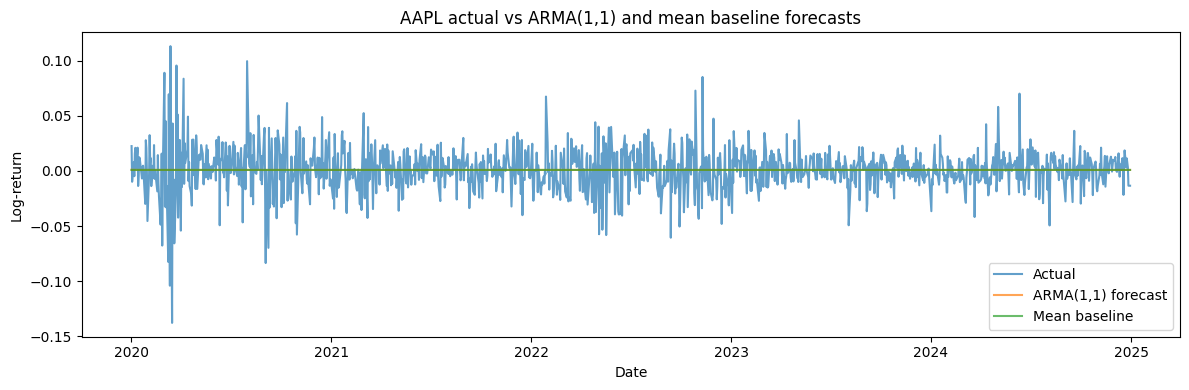

In [15]:
plt.figure(figsize=(12, 4))

plt.plot(
    comparison.index,
    comparison["actual"],
    label="Actual",
    alpha=0.7
)

plt.plot(
    comparison.index,
    comparison["arma_forecast"],
    label="ARMA(1,1) forecast",
    alpha=0.7
)

plt.plot(
    comparison.index,
    comparison["mean_forecast"],
    label="Mean baseline",
    alpha=0.7
)

plt.title("AAPL actual vs ARMA(1,1) and mean baseline forecasts")
plt.xlabel("Date")
plt.ylabel("Log-return")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
model_results = pd.DataFrame({
    "Model": ["ARMA(1,1)", "Mean baseline"],
    "RMSE": [arma_rmse, mean_rmse],
    "MAE": [arma_mae, mean_mae]
})

model_results

,Model,RMSE,MAE
0,"ARMA(1,1)",0.01994,0.014026
1,Mean baseline,0.01994,0.014026
